# Análise de Acidentes Rodoviários - Distrito de Setúbal
## Grupo 15

---

## Parte 1: Análise Exploratória de Dados

### Objetivos:
- Analisar dados de acidentes rodoviários no distrito de Setúbal
- Identificar padrões temporais, geográficos e demográficos
- Visualizar as principais tendências e características dos acidentes
- Preparar dados para a Parte 2 do projeto

## 1. Importação de Bibliotecas

In [3]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Análise temporal
from datetime import datetime, timedelta

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ Bibliotecas importadas com sucesso")

✓ Bibliotecas importadas com sucesso


## 2. Carregamento dos Dados

### 2.1 Leitura do ficheiro de dados

In [4]:
# Carregar dados de acidentes
df = pd.read_excel('dados/acidentes-sample.xlsx')

print(f"Total de registos: {len(df)}")
print(f"Colunas disponíveis: {df.shape[1]}")
df.head()

Total de registos: 40209
Colunas disponíveis: 40


,Id. Acidente,Datahora,Sexo,Lesões a 30 dias,Licença Condução,Teste Alcool,Acções Condutores,Inf. Comp. a Acções e Manobras,Nomeoutrosfactores,Tempo Condução Continuada,Acessórios Condutores,Categoria Veículos,Tipo Veiculo,Tipo Serviço,Veiculo Especial,Ano matricula,Inspecção Periódica,Certificado Adr,Carga Lotação,Pneus,Seguros,Distrito,Concelho,Condutor Gr.Etario(<=5) SUM,Condutor Gr.Etario(6-9) SUM,Condutor Gr.Etario(10-14) SUM,Condutor Gr.Etario(15-17) SUM,Condutor Gr.Etario(18-20) SUM,Condutor Gr.Etario(21-24) SUM,Condutor Gr.Etario(25-29) SUM,Condutor Gr.Etario(30-34) SUM,Condutor Gr.Etario(35-39) SUM,Condutor Gr.Etario(40-44) SUM,Condutor Gr.Etario(45-49) SUM,Condutor Gr.Etario(50-54) SUM,Condutor Gr.Etario(55-59) SUM,Condutor Gr.Etario(65-69) SUM,Condutor Gr.Etario(70-74) SUM,Condutor Gr.Etario(>=75) SUM,Condutor Gr.Etario(Não Def.) SUM
0,20201824120,2020:01:01 00:20:00,Masculino,Ferido leve,Com licença/ carta adequada ao veiculo,Submetido ao teste do álcoolemia,Em marcha normal,Não identificada,Normal,Menos de 1 hora,Cinto de segurança,Automóvel ligeiro,Passageiros,Particular,NÃO DEFINIDO,2014.0,Válida,NÃO DEFINIDO,Sem carga,Sem deficiência,Com seguro,Porto,Maia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,20201824546,2020:01:01 01:00:00,Masculino,Ileso,Com licença/ carta adequada ao veiculo,Submetido ao teste do álcoolemia,Em marcha normal,Não identificada,Normal,Ignorada,Cinto de segurança,Automóvel ligeiro,Passageiros,Particular,NÃO DEFINIDO,2016.0,Não obrigatória,NÃO DEFINIDO,Sem carga,Sem deficiência,Com seguro,Faro,Albufeira,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,20201824546,2020:01:01 01:00:00,Feminino,Ileso,Com licença/ carta adequada ao veiculo,Submetido ao teste do álcoolemia,Mudança de direcção para a esquerda,Não identificada,Normal,Ignorada,Cinto de segurança,Automóvel ligeiro,Passageiros,Particular,NÃO DEFINIDO,2015.0,Válida,NÃO DEFINIDO,Sem carga,Sem deficiência,Com seguro,Faro,Albufeira,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,20201823597,2020:01:01 01:05:00,Masculino,Ferido leve,Sem licença/carta,Não submetido outra,Travagem brusca,Não identificada,Sono/sonolência,Menos de 1 hora,Capacete,Motociclo cilindrada <= 125cc,NÃO DEFINIDO,Particular,NÃO DEFINIDO,2018.0,Não obrigatória,NÃO DEFINIDO,Sem carga,Sem deficiência,Sem seguro,Lisboa,Cascais,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,20201824596,2020:01:01 02:11:00,Masculino,Ferido leve,Com licença/ carta adequada ao veiculo,Não submetido por lesão ou morte decorrente do...,Em marcha normal,Não identificada,Normal,Menos de 1 hora,Cinto de segurança,Automóvel ligeiro,Passageiros,Particular,NÃO DEFINIDO,1996.0,Válida,NÃO DEFINIDO,Sem carga,Sem deficiência,Com seguro,Faro,Faro,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


### 2.2 Filtrar dados do distrito de Setúbal

In [6]:
# Filtrar apenas acidentes no distrito de Setúbal
df_setubal = df[df['Distrito'] == 'Setúbal'].copy()

print(f"Total de acidentes em Setúbal: {len(df_setubal)}")
print(f"Percentagem do total: {len(df_setubal)/len(df)*100:.2f}%")
df_setubal.head()

Total de acidentes em Setúbal: 3234
Percentagem do total: 8.04%


,Id. Acidente,Datahora,Sexo,Lesões a 30 dias,Licença Condução,Teste Alcool,Acções Condutores,Inf. Comp. a Acções e Manobras,Nomeoutrosfactores,Tempo Condução Continuada,Acessórios Condutores,Categoria Veículos,Tipo Veiculo,Tipo Serviço,Veiculo Especial,Ano matricula,Inspecção Periódica,Certificado Adr,Carga Lotação,Pneus,Seguros,Distrito,Concelho,Condutor Gr.Etario(<=5) SUM,Condutor Gr.Etario(6-9) SUM,Condutor Gr.Etario(10-14) SUM,Condutor Gr.Etario(15-17) SUM,Condutor Gr.Etario(18-20) SUM,Condutor Gr.Etario(21-24) SUM,Condutor Gr.Etario(25-29) SUM,Condutor Gr.Etario(30-34) SUM,Condutor Gr.Etario(35-39) SUM,Condutor Gr.Etario(40-44) SUM,Condutor Gr.Etario(45-49) SUM,Condutor Gr.Etario(50-54) SUM,Condutor Gr.Etario(55-59) SUM,Condutor Gr.Etario(65-69) SUM,Condutor Gr.Etario(70-74) SUM,Condutor Gr.Etario(>=75) SUM,Condutor Gr.Etario(Não Def.) SUM
26,20201823558,2020:01:01 07:00:00,Masculino,Ferido leve,Com licença/ carta adequada ao veiculo,Submetido ao teste do álcoolemia,Em marcha normal,Não identificada,Distracção,De 1 a 3 horas,Cinto de segurança,Automóvel ligeiro,Passageiros,Particular,NÃO DEFINIDO,2004.0,Válida,NÃO DEFINIDO,Sem carga,Sem deficiência,Com seguro,Setúbal,Alcochete,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
41,20201826531,2020:01:01 11:26:00,Masculino,Ferido leve,Sem licença/carta,Submetido ao teste do álcoolemia,Em marcha normal,Manobra irregular,Normal,Menos de 1 hora,Cinto de segurança,Automóvel ligeiro,Passageiros,Particular,NÃO DEFINIDO,1997.0,Válida,NÃO DEFINIDO,Sem carga,Com deficiência,Com seguro,Setúbal,Almada,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
97,20201828061,2020:01:01 21:00:00,Masculino,Ferido leve,Com licença/ carta adequada ao veiculo,Submetido ao teste do álcoolemia,Início de marcha,Desrespeito das distâncias de segurança,Normal,Menos de 1 hora,Capacete,Motociclo cilindrada <= 125cc,NÃO DEFINIDO,Particular,NÃO DEFINIDO,2016.0,Não obrigatória,NÃO DEFINIDO,Sem carga,Sem deficiência,Com seguro,Setúbal,Almada,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
98,20201828061,2020:01:01 21:00:00,NÃO DEFINIDO,Ileso,NÃO DEFINIDO,Não submetido condutor não contactado na altur...,Parado ou estacionado,Não identificada,Normal,NÃO DEFINIDO,NÃO DEFINIDO,Automóvel ligeiro,Passageiros,Particular,NÃO DEFINIDO,2018.0,Não obrigatória,NÃO DEFINIDO,Sem carga,Sem deficiência,Com seguro,Setúbal,Almada,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
115,20201820381,2020:01:02 07:50:00,Feminino,Ileso,Com licença/ carta adequada ao veiculo,Submetido ao teste do álcoolemia,Em marcha normal,Não identificada,Normal,Ignorada,Cinto de segurança,Automóvel ligeiro,Passageiros,Particular,NÃO DEFINIDO,2018.0,Válida,NÃO DEFINIDO,Sem carga,Sem deficiência,Com seguro,Setúbal,Setubal,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


## 3. Exploração Inicial dos Dados

### 3.1 Informações gerais sobre o dataset

In [7]:
# Informações sobre tipos de dados e valores não nulos
print("=" * 60)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 60)
df_setubal.info()

print("\n" + "=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
df_setubal.describe()

INFORMAÇÕES GERAIS DO DATASET
<class 'pandas.core.frame.DataFrame'>
Index: 3234 entries, 26 to 40184
Data columns (total 40 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Id. Acidente                      3234 non-null   int64  
 1   Datahora                          3234 non-null   object 
 2   Sexo                              3234 non-null   object 
 3   Lesões a 30 dias                  3234 non-null   object 
 4   Licença Condução                  3234 non-null   object 
 5   Teste Alcool                      3234 non-null   object 
 6   Acções Condutores                 3234 non-null   object 
 7   Inf. Comp. a Acções e Manobras    3234 non-null   object 
 8   Nomeoutrosfactores                3234 non-null   object 
 9   Tempo Condução Continuada         3234 non-null   object 
 10  Acessórios Condutores             3234 non-null   object 
 11  Categoria Veículos                3234 non

,Id. Acidente,Ano matricula,Condutor Gr.Etario(<=5) SUM,Condutor Gr.Etario(6-9) SUM,Condutor Gr.Etario(10-14) SUM,Condutor Gr.Etario(15-17) SUM,Condutor Gr.Etario(18-20) SUM,Condutor Gr.Etario(21-24) SUM,Condutor Gr.Etario(25-29) SUM,Condutor Gr.Etario(30-34) SUM,Condutor Gr.Etario(35-39) SUM,Condutor Gr.Etario(40-44) SUM,Condutor Gr.Etario(45-49) SUM,Condutor Gr.Etario(50-54) SUM,Condutor Gr.Etario(55-59) SUM,Condutor Gr.Etario(65-69) SUM,Condutor Gr.Etario(70-74) SUM,Condutor Gr.Etario(>=75) SUM,Condutor Gr.Etario(Não Def.) SUM
count,3.234000e+03,3071.00000,3234.0,3234.0,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000
mean,2.020216e+10,2007.51449,0.0,0.0,0.001546,0.008349,0.040816,0.076376,0.107607,0.092764,0.092146,0.112863,0.109771,0.076994,0.074830,0.037724,0.039270,0.049165,0.022263
std,1.549232e+06,8.09015,0.0,0.0,0.039296,0.091004,0.197895,0.265640,0.309931,0.290147,0.290344,0.316475,0.312653,0.266624,0.263157,0.190558,0.194267,0.216246,0.149643
min,2.020182e+10,1914.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.020187e+10,2001.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.020192e+10,2008.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.020196e+10,2015.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.021204e+10,2020.00000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


### 3.2 Verificar valores em falta

In [8]:
# Análise de valores em falta
missing_data = pd.DataFrame({
    'Coluna': df_setubal.columns,
    'Valores em Falta': df_setubal.isnull().sum(),
    'Percentagem (%)': (df_setubal.isnull().sum() / len(df_setubal) * 100).round(2)
}).sort_values('Valores em Falta', ascending=False)

missing_data[missing_data['Valores em Falta'] > 0]

,Coluna,Valores em Falta,Percentagem (%)
Ano matricula,Ano matricula,163,5.04


## 4. Análise Temporal

### 4.1 Distribuição de acidentes por ano

IndexError: index 0 is out of bounds for axis 0 with size 0

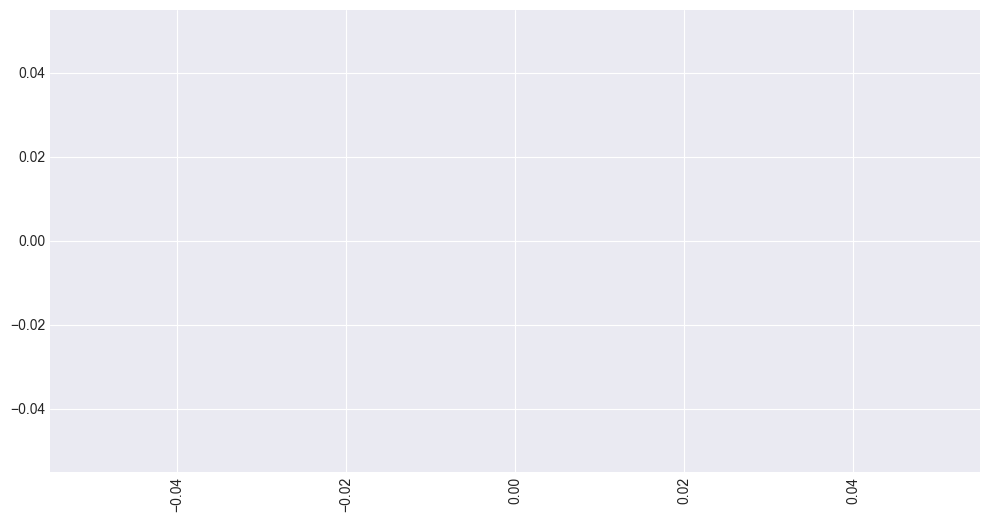

In [10]:
# Converter coluna de data para datetime se necessário
if 'Datahora' in df_setubal.columns:
    df_setubal['Datahora'] = pd.to_datetime(df_setubal['Datahora'], errors='coerce')
    df_setubal['ANO'] = df_setubal['Datahora'].dt.year
    df_setubal['MES'] = df_setubal['Datahora'].dt.month
    df_setubal['DIA_SEMANA'] = df_setubal['Datahora'].dt.day_name()
    df_setubal['HORA'] = df_setubal['Datahora'].dt.hour

# Acidentes por ano
if 'ANO' in df_setubal.columns:
    acidentes_por_ano = df_setubal['ANO'].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    acidentes_por_ano.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Distribuição de Acidentes por Ano - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Número de Acidentes', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print(acidentes_por_ano)
else:
    print("⚠️ Coluna 'Datahora' não encontrada no dataset")

### 4.2 Distribuição de acidentes por mês

IndexError: index 0 is out of bounds for axis 0 with size 0

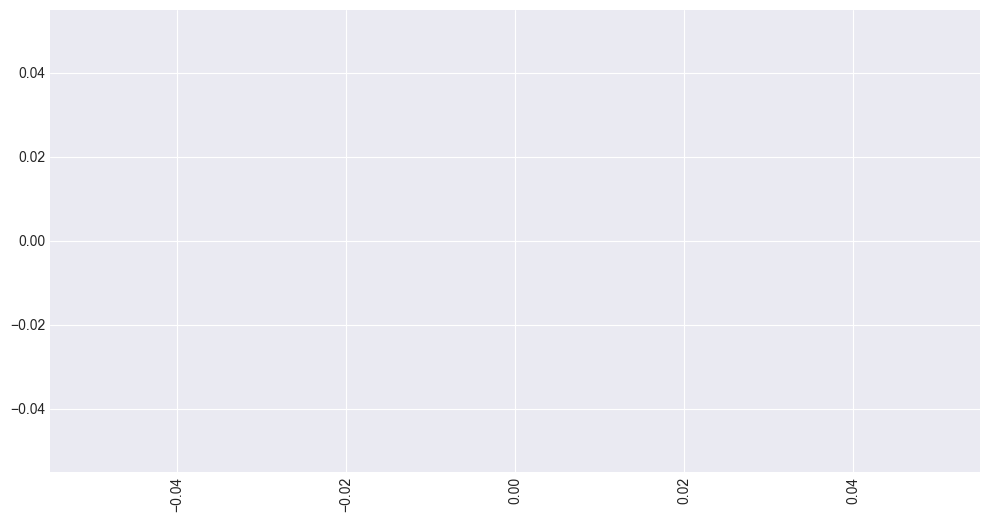

In [11]:
# Acidentes por mês
acidentes_por_mes = df_setubal['MES'].value_counts().sort_index()
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, ax = plt.subplots(figsize=(12, 6))
acidentes_por_mes.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Distribuição de Acidentes por Mês - Setúbal', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Número de Acidentes', fontsize=12)
ax.set_xticklabels(meses_nomes, rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Distribuição de acidentes por dia da semana

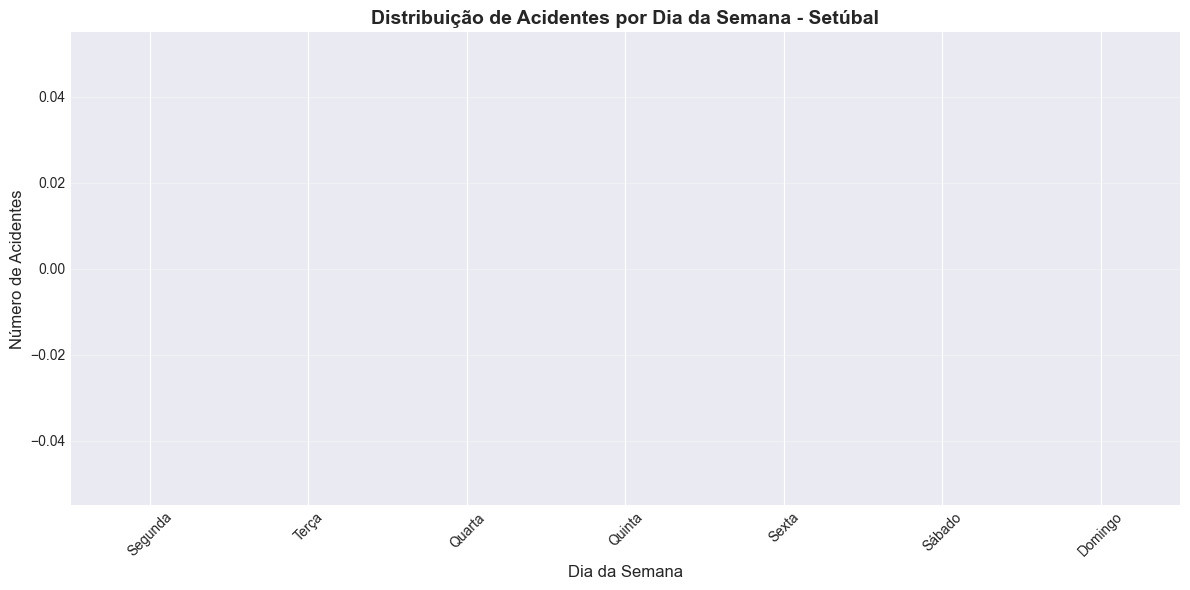

In [12]:
# Acidentes por dia da semana
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

acidentes_dia_semana = df_setubal['DIA_SEMANA'].value_counts().reindex(ordem_dias)

fig, ax = plt.subplots(figsize=(12, 6))
acidentes_dia_semana.plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Distribuição de Acidentes por Dia da Semana - Setúbal', fontsize=14, fontweight='bold')
ax.set_xlabel('Dia da Semana', fontsize=12)
ax.set_ylabel('Número de Acidentes', fontsize=12)
ax.set_xticklabels(dias_pt, rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Distribuição de acidentes por hora do dia

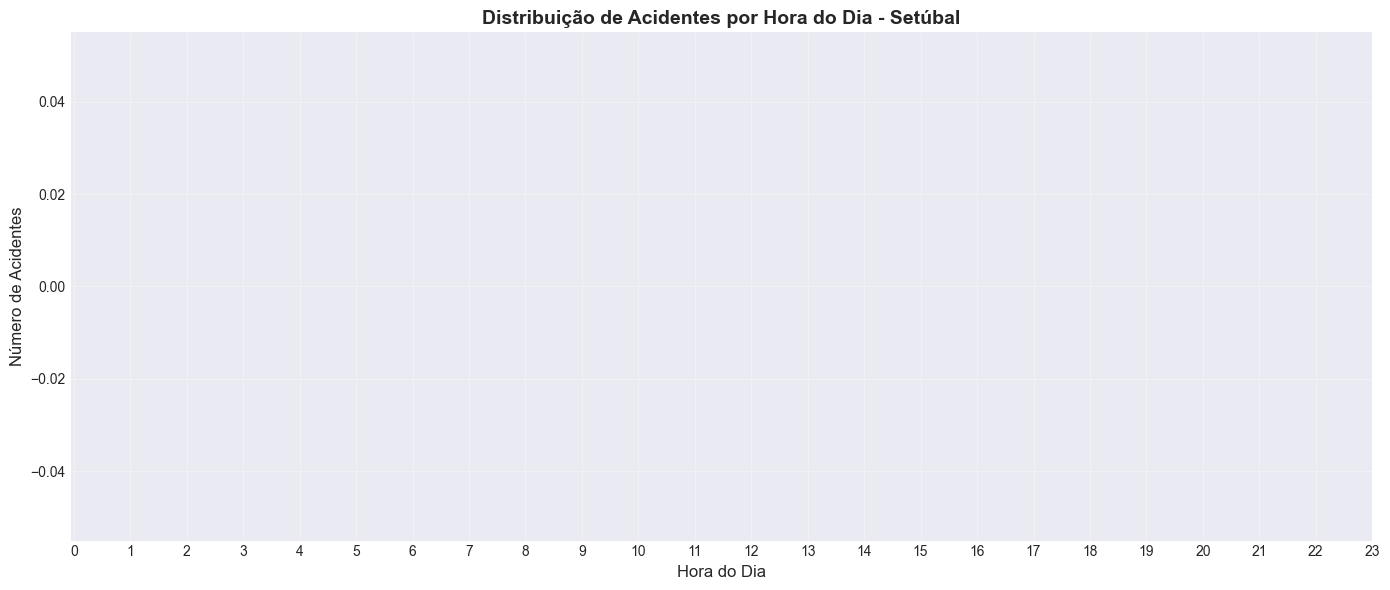

In [13]:
# Acidentes por hora
if 'HORA' in df_setubal.columns:
    acidentes_por_hora = df_setubal['HORA'].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    acidentes_por_hora.plot(kind='line', marker='o', ax=ax, color='darkred', linewidth=2)
    ax.set_title('Distribuição de Acidentes por Hora do Dia - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hora do Dia', fontsize=12)
    ax.set_ylabel('Número de Acidentes', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 24))
    plt.tight_layout()
    plt.show()

## 5. Análise Geográfica

### 5.1 Distribuição por concelho

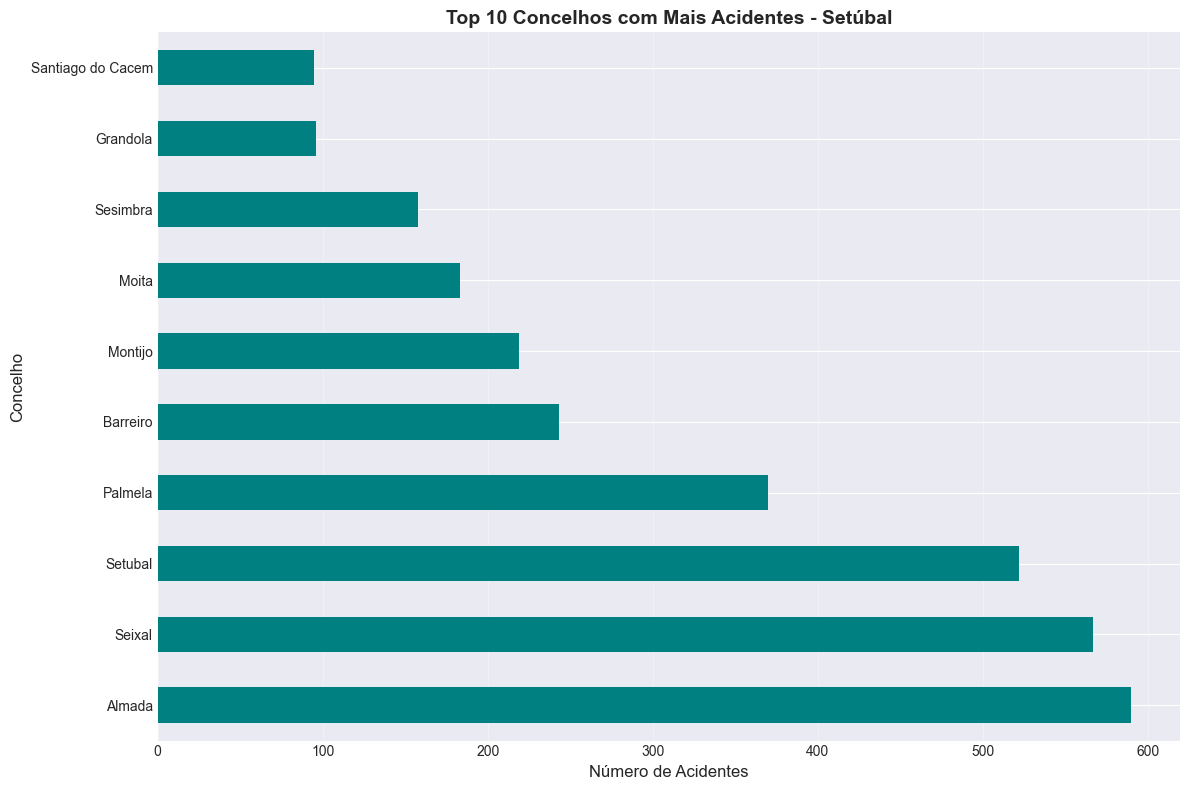


Distribuição completa por concelho:
Concelho
Almada               590
Seixal               567
Setubal              522
Palmela              370
Barreiro             243
Montijo              219
Moita                183
Sesimbra             158
Grandola              96
Santiago do Cacem     95
Alcacer do Sal        94
Alcochete             56
Sines                 41
Name: count, dtype: int64


In [14]:
# Acidentes por concelho
if 'Concelho' in df_setubal.columns:
    acidentes_concelho = df_setubal['Concelho'].value_counts().head(10)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    acidentes_concelho.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 10 Concelhos com Mais Acidentes - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Número de Acidentes', fontsize=12)
    ax.set_ylabel('Concelho', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nDistribuição completa por concelho:")
    print(df_setubal['Concelho'].value_counts())
else:
    print("⚠️ Coluna 'Concelho' não encontrada no dataset")

### 5.2 Tipo de via onde ocorreram os acidentes

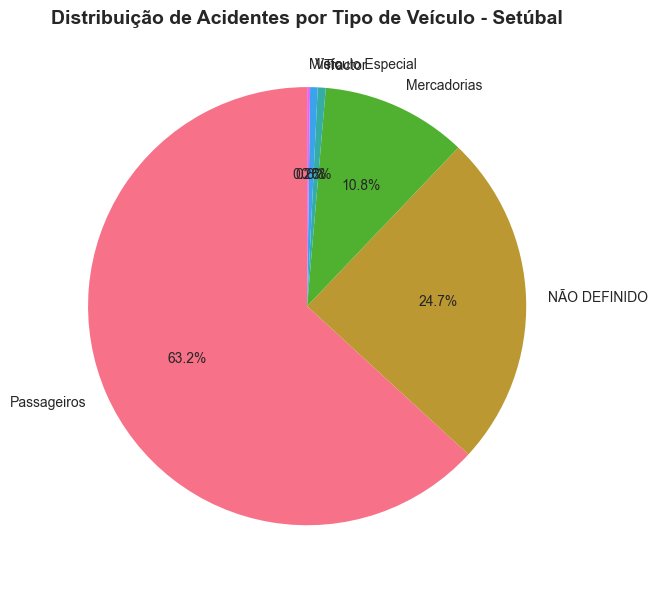

In [15]:
# Tipo de via
if 'Tipo Veiculo' in df_setubal.columns:
    tipo_veiculo = df_setubal['Tipo Veiculo'].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    tipo_veiculo.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
    ax.set_title('Distribuição de Acidentes por Tipo de Veículo - Setúbal', fontsize=14, fontweight='bold')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Coluna 'Tipo Veiculo' não encontrada no dataset")

## 6. Análise de Gravidade

### 6.1 Distribuição por tipo de acidente

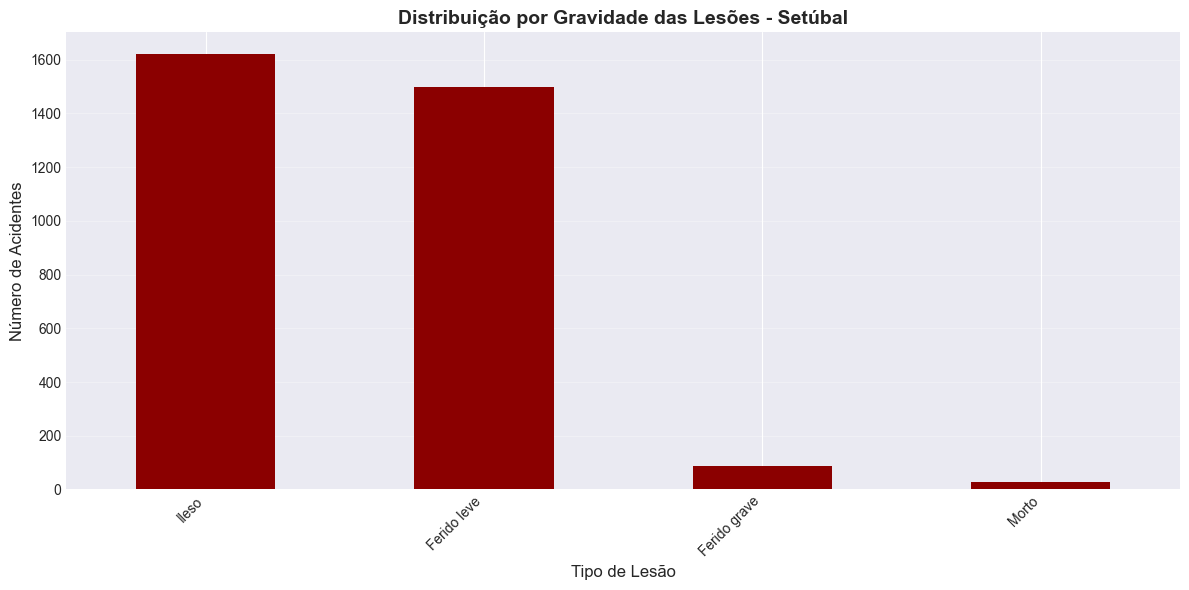

Lesões a 30 dias
Ileso           1621
Ferido leve     1498
Ferido grave      88
Morto             27
Name: count, dtype: int64


In [16]:
# Tipo de acidente / Gravidade (usando a coluna Lesões a 30 dias)
if 'Lesões a 30 dias' in df_setubal.columns:
    lesoes = df_setubal['Lesões a 30 dias'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    lesoes.plot(kind='bar', ax=ax, color='darkred')
    ax.set_title('Distribuição por Gravidade das Lesões - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tipo de Lesão', fontsize=12)
    ax.set_ylabel('Número de Acidentes', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(lesoes)
else:
    print("⚠️ Coluna 'Lesões a 30 dias' não encontrada no dataset")

### 6.2 Vítimas nos acidentes

Colunas de grupos etários encontradas:
['Condutor Gr.Etario(<=5) SUM', 'Condutor Gr.Etario(6-9) SUM', 'Condutor Gr.Etario(10-14) SUM', 'Condutor Gr.Etario(15-17) SUM', 'Condutor Gr.Etario(18-20) SUM', 'Condutor Gr.Etario(21-24) SUM', 'Condutor Gr.Etario(25-29) SUM', 'Condutor Gr.Etario(30-34) SUM', 'Condutor Gr.Etario(35-39) SUM', 'Condutor Gr.Etario(40-44) SUM', 'Condutor Gr.Etario(45-49) SUM', 'Condutor Gr.Etario(50-54) SUM', 'Condutor Gr.Etario(55-59) SUM', 'Condutor Gr.Etario(65-69) SUM', 'Condutor Gr.Etario(70-74) SUM', 'Condutor Gr.Etario(>=75) SUM', 'Condutor Gr.Etario(Não Def.) SUM']


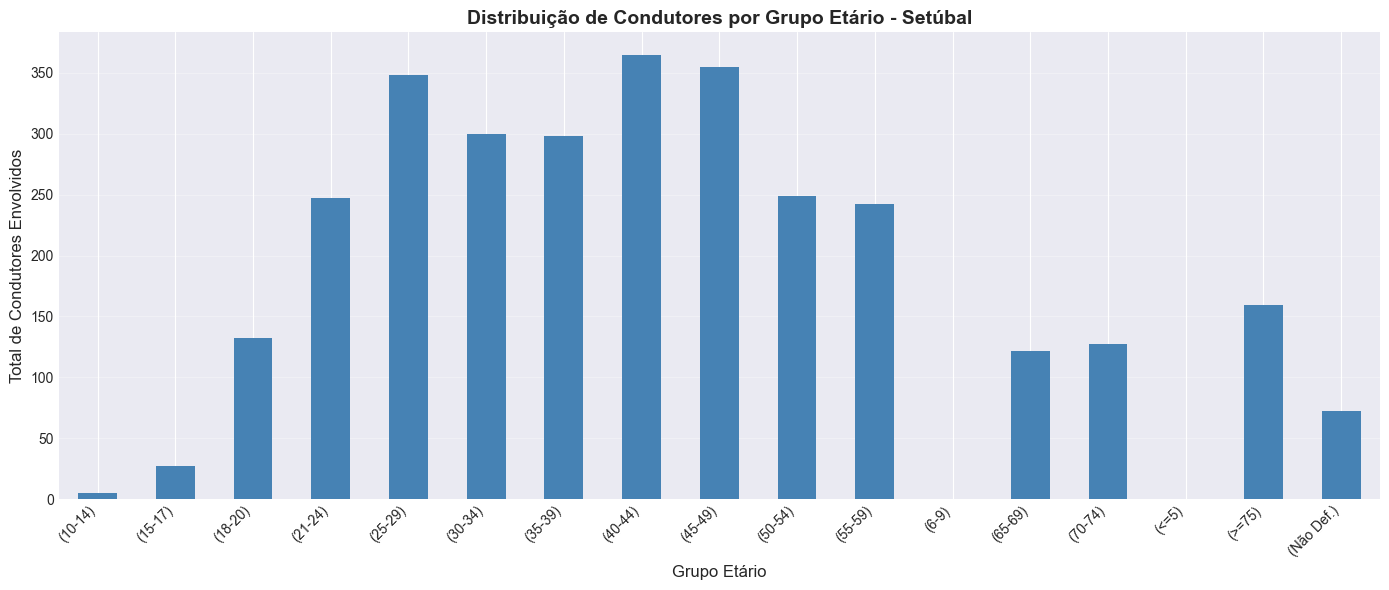


Resumo por grupo etário:
(10-14)         5
(15-17)        27
(18-20)       132
(21-24)       247
(25-29)       348
(30-34)       300
(35-39)       298
(40-44)       365
(45-49)       355
(50-54)       249
(55-59)       242
(6-9)           0
(65-69)       122
(70-74)       127
(<=5)           0
(>=75)        159
(Não Def.)     72
dtype: int64


In [17]:
# Análise de vítimas por grupo etário
colunas_grupos_etarios = [col for col in df_setubal.columns if 'Gr.Etario' in col and 'SUM' in col]

if colunas_grupos_etarios:
    print("Colunas de grupos etários encontradas:")
    print(colunas_grupos_etarios)
    
    # Criar um resumo dos grupos etários
    grupos_etarios_data = {}
    for col in colunas_grupos_etarios:
        # Extrair o nome do grupo etário
        grupo = col.replace('Condutor Gr.Etario', '').replace(' SUM', '').strip()
        grupos_etarios_data[grupo] = df_setubal[col].sum()
    
    # Criar gráfico
    grupos_df = pd.Series(grupos_etarios_data).sort_index()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    grupos_df.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Distribuição de Condutores por Grupo Etário - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Grupo Etário', fontsize=12)
    ax.set_ylabel('Total de Condutores Envolvidos', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\nResumo por grupo etário:")
    print(grupos_df)
else:
    print("⚠️ Não foram encontradas colunas de grupos etários.")

## 7. Análise de Condições

### 7.1 Condições meteorológicas

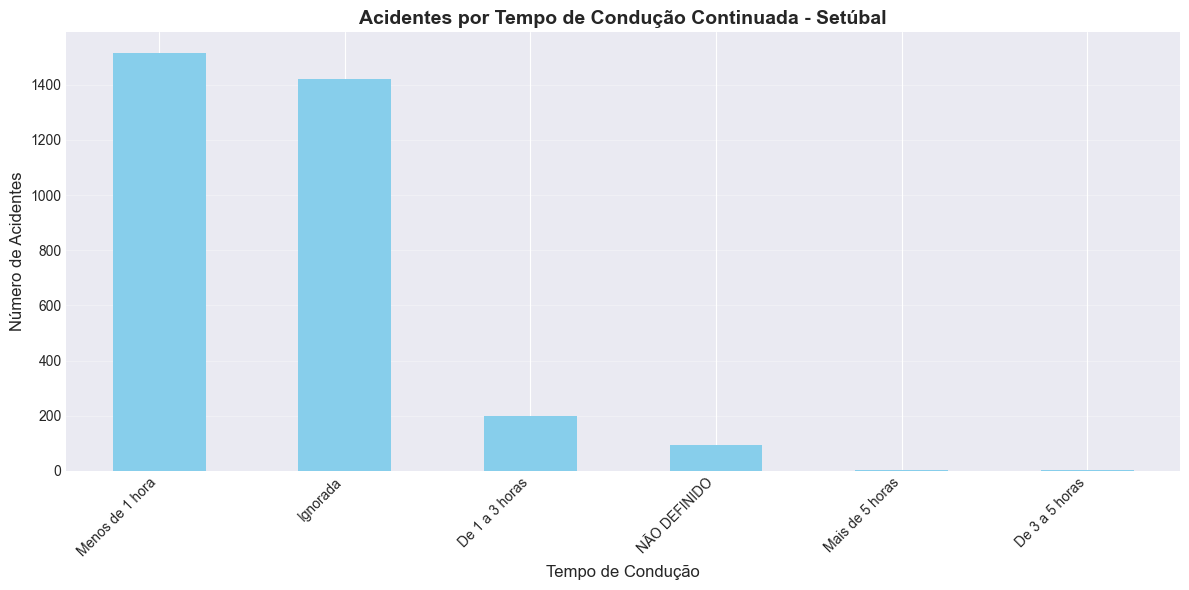

In [18]:
# Condições meteorológicas
if 'Tempo Condução Continuada' in df_setubal.columns:
    tempo_conducao = df_setubal['Tempo Condução Continuada'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    tempo_conducao.plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title('Acidentes por Tempo de Condução Continuada - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tempo de Condução', fontsize=12)
    ax.set_ylabel('Número de Acidentes', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Coluna 'Tempo Condução Continuada' não encontrada no dataset")
    print("Nota: O dataset não parece ter informação sobre condições meteorológicas")

### 7.2 Luminosidade

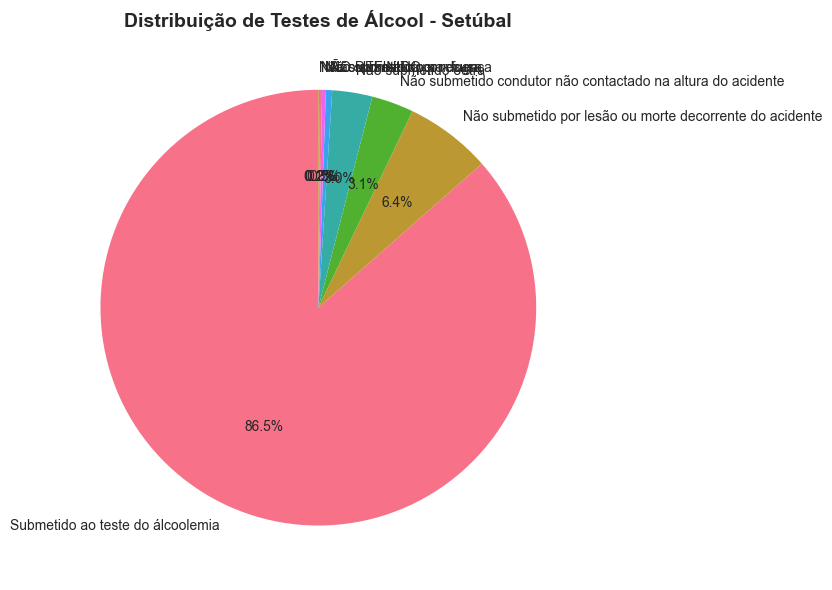

In [19]:
# Análise de teste de álcool
if 'Teste Alcool' in df_setubal.columns:
    teste_alcool = df_setubal['Teste Alcool'].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    teste_alcool.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
    ax.set_title('Distribuição de Testes de Álcool - Setúbal', fontsize=14, fontweight='bold')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Coluna 'Teste Alcool' não encontrada no dataset")

### 7.3 Estado da via

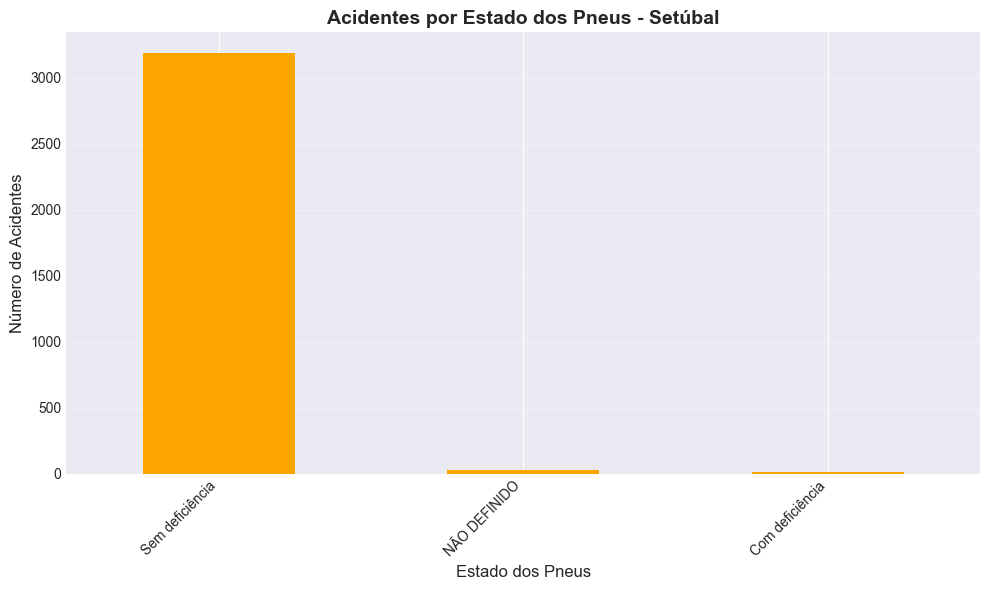

In [20]:
# Estado dos pneus
if 'Pneus' in df_setubal.columns:
    estado_pneus = df_setubal['Pneus'].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    estado_pneus.plot(kind='bar', ax=ax, color='orange')
    ax.set_title('Acidentes por Estado dos Pneus - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Estado dos Pneus', fontsize=12)
    ax.set_ylabel('Número de Acidentes', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Coluna 'Pneus' não encontrada no dataset")

## 8. Análise de Veículos

### 8.1 Tipos de veículos envolvidos

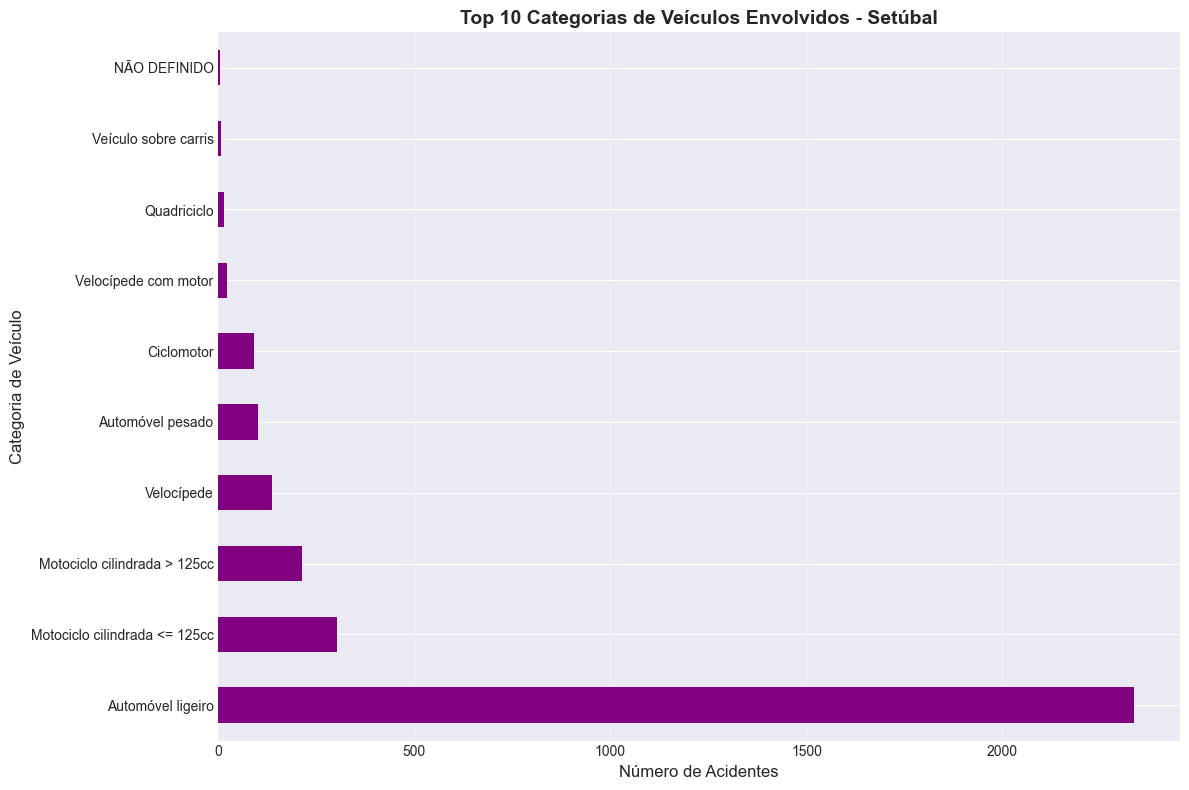

In [21]:
# Tipos de veículos
if 'Categoria Veículos' in df_setubal.columns:
    categoria_veiculo = df_setubal['Categoria Veículos'].value_counts().head(10)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    categoria_veiculo.plot(kind='barh', ax=ax, color='purple')
    ax.set_title('Top 10 Categorias de Veículos Envolvidos - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Número de Acidentes', fontsize=12)
    ax.set_ylabel('Categoria de Veículo', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Coluna 'Categoria Veículos' não encontrada no dataset")

## 9. Análise Demográfica

### 9.1 Idade dos condutores

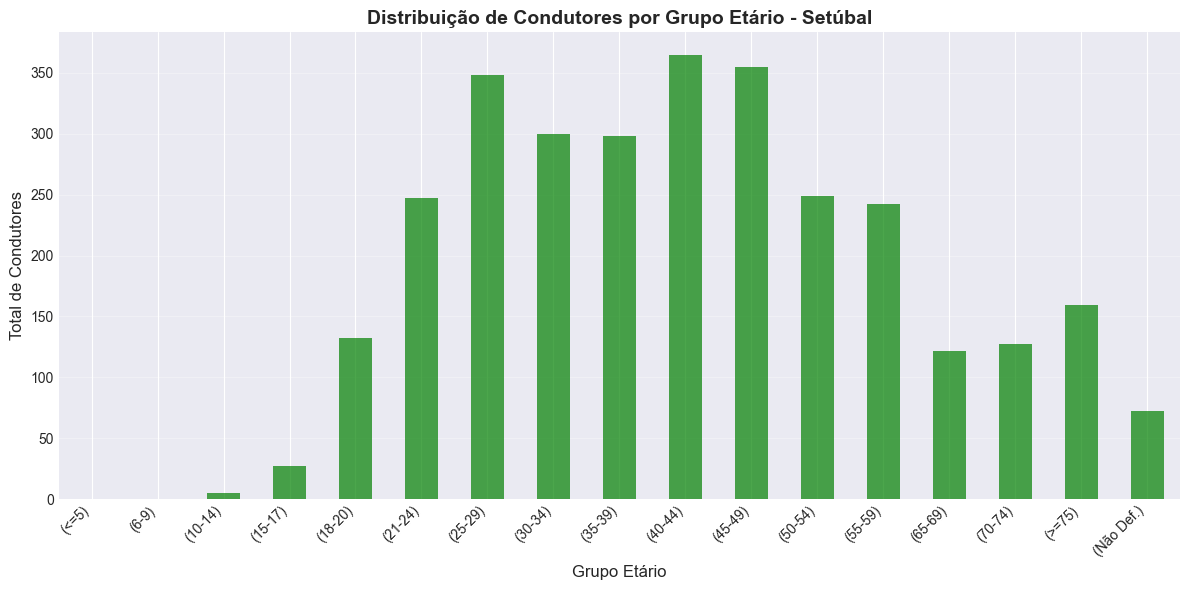

Estatísticas por grupo etário:
count     17.000000
mean     179.294118
std      130.838529
min        0.000000
25%       72.000000
50%      159.000000
75%      298.000000
max      365.000000
dtype: float64


In [22]:
# Análise de grupos etários dos condutores (visualização consolidada)
colunas_grupos_etarios = [col for col in df_setubal.columns if 'Gr.Etario' in col and 'SUM' in col]

if colunas_grupos_etarios:
    # Somar todos os condutores por grupo etário
    grupos_etarios_data = {}
    for col in colunas_grupos_etarios:
        grupo = col.replace('Condutor Gr.Etario', '').replace(' SUM', '').strip()
        grupos_etarios_data[grupo] = df_setubal[col].sum()
    
    # Criar série e ordenar
    grupos_series = pd.Series(grupos_etarios_data)
    
    # Criar histograma
    fig, ax = plt.subplots(figsize=(12, 6))
    grupos_series.plot(kind='bar', ax=ax, color='green', alpha=0.7)
    ax.set_title('Distribuição de Condutores por Grupo Etário - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Grupo Etário', fontsize=12)
    ax.set_ylabel('Total de Condutores', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("Estatísticas por grupo etário:")
    print(grupos_series.describe())
else:
    print("⚠️ Colunas de grupos etários não encontradas")

### 9.2 Género dos condutores

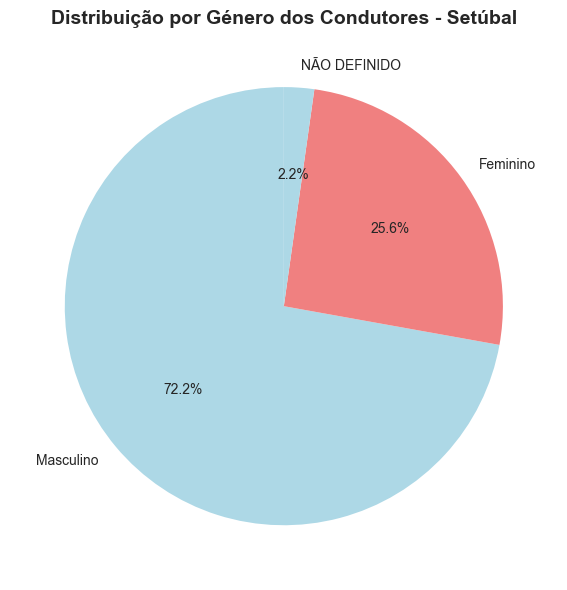

In [23]:
# Género dos condutores
if 'Sexo' in df_setubal.columns:
    genero = df_setubal['Sexo'].value_counts()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    genero.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
    ax.set_title('Distribuição por Género dos Condutores - Setúbal', fontsize=14, fontweight='bold')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Coluna 'Sexo' não encontrada no dataset")

## 10. Correlações e Análises Cruzadas

### 10.1 Matriz de correlação (variáveis numéricas)

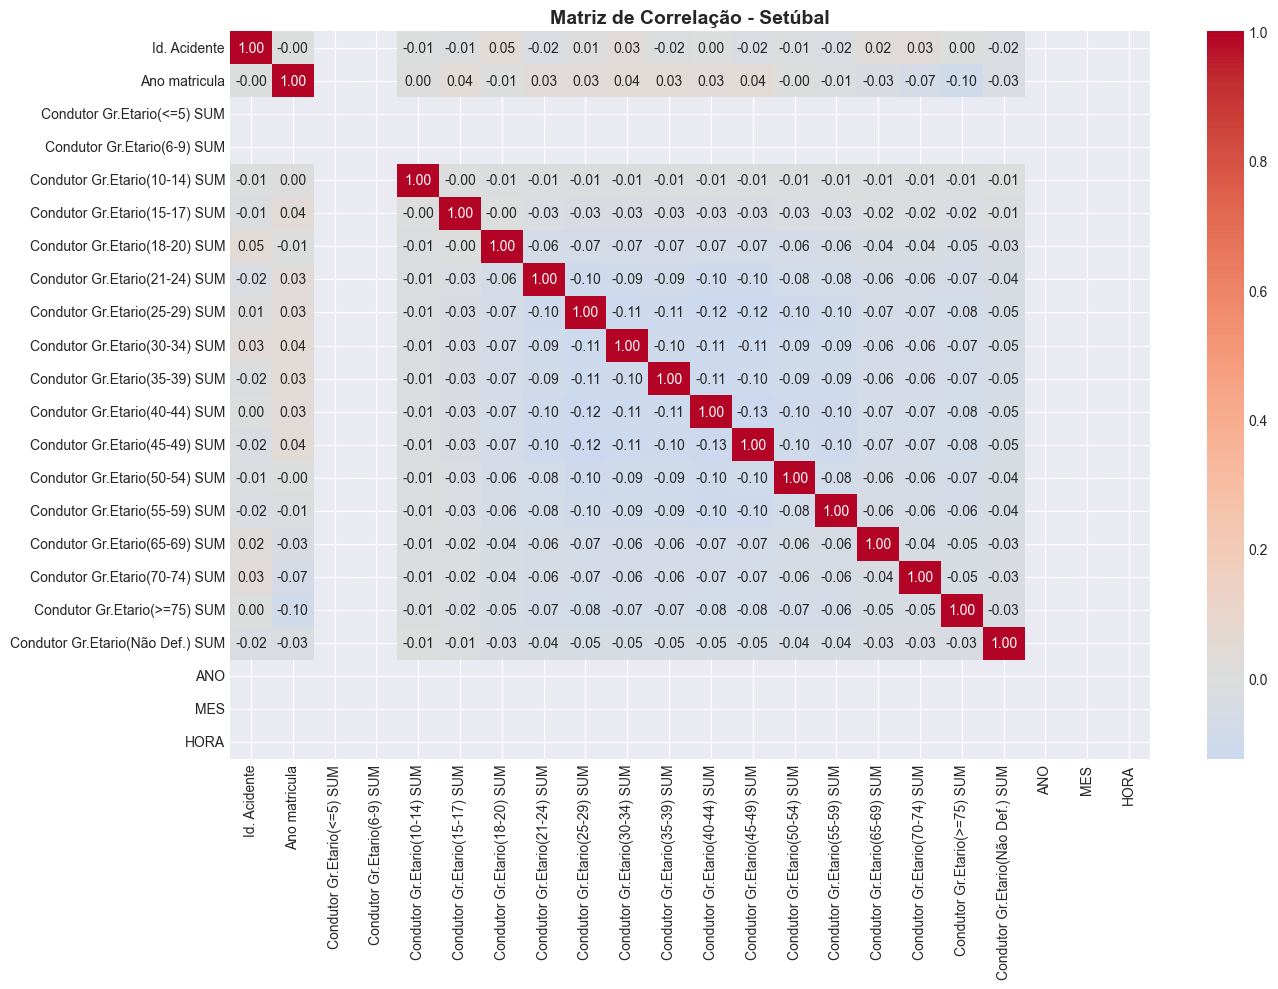

In [24]:
# Selecionar apenas colunas numéricas
numeric_cols = df_setubal.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    correlation_matrix = df_setubal[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    ax.set_title('Matriz de Correlação - Setúbal', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 10.2 Análise: Hora do dia vs Gravidade

TypeError: no numeric data to plot

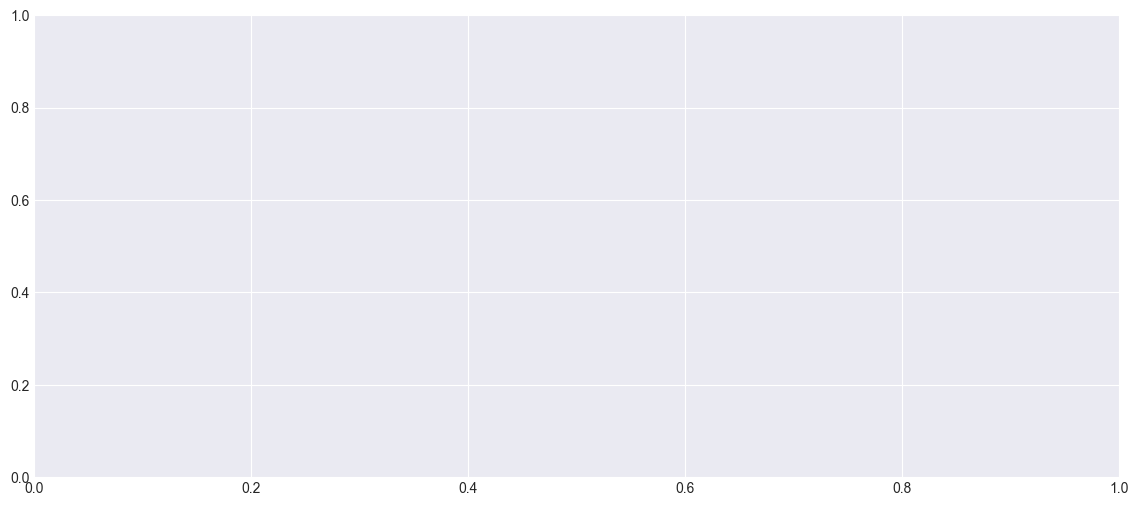

In [25]:
# Cruzamento: Hora vs Gravidade (Lesões)
if 'HORA' in df_setubal.columns and 'Lesões a 30 dias' in df_setubal.columns:
    crosstab = pd.crosstab(df_setubal['HORA'], df_setubal['Lesões a 30 dias'])
    
    fig, ax = plt.subplots(figsize=(14, 6))
    crosstab.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title('Acidentes por Hora e Gravidade das Lesões - Setúbal', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hora do Dia', fontsize=12)
    ax.set_ylabel('Número de Acidentes', fontsize=12)
    ax.legend(title='Gravidade', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Não foi possível criar análise cruzada (colunas não encontradas)")

## 11. Resumo e Principais Conclusões

### 11.1 Principais estatísticas

In [26]:
print("="*80)
print("RESUMO DA ANÁLISE - ACIDENTES RODOVIÁRIOS EM SETÚBAL")
print("="*80)

print(f"\n📊 Total de acidentes analisados: {len(df_setubal)}")

if 'ANO' in df_setubal.columns:
    print(f"📅 Período analisado: {df_setubal['ANO'].min()} - {df_setubal['ANO'].max()}")

if 'Concelho' in df_setubal.columns:
    concelho_mais_acidentes = df_setubal['Concelho'].value_counts().index[0]
    print(f"🏘️ Concelho com mais acidentes: {concelho_mais_acidentes}")

if 'MES' in df_setubal.columns:
    mes_mais_acidentes = df_setubal['MES'].value_counts().index[0]
    meses_nomes_dict = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
                       7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}
    print(f"📆 Mês com mais acidentes: {meses_nomes_dict.get(mes_mais_acidentes, mes_mais_acidentes)}")

if 'DIA_SEMANA' in df_setubal.columns:
    dia_mais_acidentes = df_setubal['DIA_SEMANA'].value_counts().index[0]
    print(f"📅 Dia da semana com mais acidentes: {dia_mais_acidentes}")

if 'HORA' in df_setubal.columns:
    hora_mais_acidentes = df_setubal['HORA'].value_counts().index[0]
    print(f"⏰ Hora com mais acidentes: {hora_mais_acidentes}h")

if 'Lesões a 30 dias' in df_setubal.columns:
    lesao_mais_comum = df_setubal['Lesões a 30 dias'].value_counts().index[0]
    print(f"⚠️ Tipo de lesão mais comum: {lesao_mais_comum}")

if 'Sexo' in df_setubal.columns:
    genero_counts = df_setubal['Sexo'].value_counts()
    print(f"\n👥 Género dos condutores:")
    for genero, count in genero_counts.items():
        percentagem = (count / len(df_setubal)) * 100
        print(f"   {genero}: {count} ({percentagem:.1f}%)")

print("\n" + "="*80)

RESUMO DA ANÁLISE - ACIDENTES RODOVIÁRIOS EM SETÚBAL

📊 Total de acidentes analisados: 3234
📅 Período analisado: nan - nan
🏘️ Concelho com mais acidentes: Almada


IndexError: index 0 is out of bounds for axis 0 with size 0

### 11.2 Observações e padrões identificados

**Temporal:**
- [Adicionar observações sobre tendências ao longo dos anos]
- [Adicionar observações sobre sazonalidade]
- [Adicionar observações sobre dias/horas críticas]

**Geográfico:**
- [Adicionar observações sobre concelhos mais afetados]
- [Adicionar observações sobre tipos de vias]

**Gravidade:**
- [Adicionar observações sobre tipos de acidentes]
- [Adicionar observações sobre vítimas]

**Condições:**
- [Adicionar observações sobre condições meteorológicas]
- [Adicionar observações sobre luminosidade]
- [Adicionar observações sobre estado da via]

**Demográfico:**
- [Adicionar observações sobre perfil dos condutores]
- [Adicionar observações sobre veículos envolvidos]

## 12. Exportação de Dados Tratados

In [ ]:
# Guardar dataset tratado para uso futuro
df_setubal.to_csv('dados/acidentes_setubal_tratado.csv', index=False, encoding='utf-8')
df_setubal.to_excel('dados/acidentes_setubal_tratado.xlsx', index=False)

print("✓ Dados exportados com sucesso!")
print(f"  - dados/acidentes_setubal_tratado.csv")
print(f"  - dados/acidentes_setubal_tratado.xlsx")

---

## Próximos Passos

### Para a Parte 2 do Projeto:

1. **Escolha do dataset adicional**: Identificar e obter dados complementares (ex: dados demográficos, económicos, infraestrutura viária)

2. **Questões de investigação** (exemplos):
   - Qual a relação entre densidade populacional e taxa de acidentes por concelho?
   - Como é que as condições da infraestrutura viária influenciam a gravidade dos acidentes?
   - Existe correlação entre indicadores socioeconómicos e padrões de acidentes?
   - Que fatores contribuem mais para acidentes com vítimas mortais?
   - Como prever zonas de risco elevado?

3. **Análises avançadas**:
   - Modelação preditiva
   - Clustering de padrões de acidentes
   - Análise espacial avançada
   - Séries temporais e previsões